# Price Prediction: 10-Model Benchmark

This notebook trains and evaluates 10 regression models on the enriched price dataset.
It predicts `Log_Price` and reports metrics on original `Price`.

In [32]:
!pip install xgboost lightgbm catboost hyperopt


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [33]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import joblib

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.25
VAL_SIZE = 0.2
MAX_EVALS = 30

In [34]:
DATA_CANDIDATES = [
    Path("Use_Cases/Price Prediction/artifacts/car_price_enriched_latest.csv"),
    Path("artifacts/car_price_enriched_latest.csv"),
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Cannot find car_price_enriched_latest.csv in expected locations."
    )

df = pd.read_csv(data_path)
if "Price" not in df.columns:
    raise ValueError("Dataset missing required target column: Price")

if "Log_Price" not in df.columns:
    df["Log_Price"] = np.log1p(df["Price"])

drop_cols = [c for c in ["Price", "Log_Price", "Car ID"] if c in df.columns]
X = df.drop(columns=drop_cols)
y_log = df["Log_Price"]

print("Data path:", data_path)
print("Rows:", len(df), "Features:", X.shape[1])
display(df.head())

Data path: artifacts/car_price_enriched_latest.csv
Rows: 2500 Features: 26


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,...,engine_size_bin,condition_mileage_bin,new_high_mileage_flag,ev_engine_size_mismatch_flag,manual_ev_flag,weather_temp_avg_c,weather_precip_total_mm,brent_oil_usd_per_barrel,au_cpi_index,energy_pressure_index
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,...,small,"New_(71831.5, 149085.0]",1,0,0,15.075683,726.9,0.0,113.475552,0.554460
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,...,large,"Used_(71831.5, 149085.0]",0,1,1,15.066301,627.4,0.0,117.898023,0.804306
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,...,large,"New_(149085.0, 225990.5]",1,1,1,15.209041,591.9,0.0,107.700306,0.228189
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,...,large,"New_(14.999, 71831.5]",1,0,0,14.696712,759.9,0.0,103.303848,-0.020187
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,...,mid,"Like New_(149085.0, 225990.5]",0,0,0,15.068767,431.6,0.0,97.164415,-0.367032


In [35]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    sparse_threshold=0.0,
)

print("Train rows:", len(X_train_full), "Test rows:", len(X_test))
print("Train/val split:", len(X_train), "/", len(X_val))
print("Numeric features:", len(num_cols), "Categorical features:", len(cat_cols))

Train rows: 1875 Test rows: 625
Train/val split: 1500 / 375
Numeric features: 16 Categorical features: 10


In [36]:
optional_estimators = {}

try:
    from xgboost import XGBRegressor

    optional_estimators["XGBoost"] = XGBRegressor
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor

    optional_estimators["LightGBM"] = LGBMRegressor
except Exception:
    pass

try:
    from catboost import CatBoostRegressor

    optional_estimators["CatBoost"] = CatBoostRegressor
except Exception:
    pass

base_model_names = [
    "LinearRegression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "KNN",
    "SVR",
    "RandomForest",
    "GradientBoosting",
]

fallback_model_names = ["ExtraTrees", "AdaBoost", "HistGradientBoosting"]

model_names = base_model_names + list(optional_estimators.keys())[:2]
if len(model_names) < 10:
    for name in fallback_model_names:
        if len(model_names) >= 10:
            break
        model_names.append(name)

model_names = model_names[:10]
print("Models selected:", model_names)

Models selected: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'SVR', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


In [ ]:
def evaluate_on_price(y_true_log, y_pred_log):
    y_true = np.maximum(0, np.expm1(y_true_log))
    y_pred = np.maximum(0, np.expm1(y_pred_log))
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denom = np.maximum(y_true, 1e-8)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape_pct": mape}


def _int(value):
    return int(value)


def _int_or_none(value):
    return None if value is None else int(value)


def build_model(name, params):
    if name == "LinearRegression":
        return LinearRegression(
            fit_intercept=params["fit_intercept"], positive=params["positive"]
        )
    if name == "Ridge":
        return Ridge(alpha=params["alpha"], random_state=RANDOM_STATE)
    if name == "Lasso":
        return Lasso(alpha=params["alpha"], random_state=RANDOM_STATE, max_iter=5000)
    if name == "ElasticNet":
        return ElasticNet(
            alpha=params["alpha"],
            l1_ratio=params["l1_ratio"],
            random_state=RANDOM_STATE,
            max_iter=5000,
        )
    if name == "KNN":
        return KNeighborsRegressor(
            n_neighbors=_int(params["n_neighbors"]),
            weights=params["weights"],
            p=_int(params["p"]),
        )
    if name == "SVR":
        return SVR(
            C=params["C"], gamma=params["gamma"], epsilon=params["epsilon"]
        )
    if name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=_int(params["n_estimators"]),
            max_depth=_int_or_none(params["max_depth"]),
            min_samples_split=_int(params["min_samples_split"]),
            min_samples_leaf=_int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            bootstrap=params["bootstrap"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=_int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=_int(params["max_depth"]),
            min_samples_split=_int(params["min_samples_split"]),
            min_samples_leaf=_int(params["min_samples_leaf"]),
            subsample=params["subsample"],
            max_features=params["max_features"],
            random_state=RANDOM_STATE,
        )
    if name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=_int(params["n_estimators"]),
            max_depth=_int_or_none(params["max_depth"]),
            min_samples_split=_int(params["min_samples_split"]),
            min_samples_leaf=_int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            bootstrap=params["bootstrap"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if name == "AdaBoost":
        return AdaBoostRegressor(
            n_estimators=_int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            loss=params["loss"],
            random_state=RANDOM_STATE,
        )
    if name == "HistGradientBoosting":
        return HistGradientBoostingRegressor(
            max_iter=_int(params["max_iter"]),
            learning_rate=params["learning_rate"],
            max_depth=_int_or_none(params["max_depth"]),
            min_samples_leaf=_int(params["min_samples_leaf"]),
            l2_regularization=params["l2_regularization"],
            random_state=RANDOM_STATE,
        )
    if name == "XGBoost":
        model_cls = optional_estimators.get("XGBoost")
        return model_cls(
            n_estimators=_int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=_int(params["max_depth"]),
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            min_child_weight=params["min_child_weight"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if name == "LightGBM":
        model_cls = optional_estimators.get("LightGBM")
        return model_cls(
            n_estimators=_int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            num_leaves=_int(params["num_leaves"]),
            min_child_samples=_int(params["min_child_samples"]),
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            random_state=RANDOM_STATE,
            verbose=-1,
        )
    if name == "CatBoost":
        model_cls = optional_estimators.get("CatBoost")
        return model_cls(
            iterations=_int(params["iterations"]),
            learning_rate=params["learning_rate"],
            depth=_int(params["depth"]),
            l2_leaf_reg=params["l2_leaf_reg"],
            bagging_temperature=params["bagging_temperature"],
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
        )
    raise ValueError(f"Unknown model name: {name}")


def get_search_space(name):
    prefix = name.lower()
    if name == "LinearRegression":
        return {
            "fit_intercept": hp.choice(f"{prefix}_fit_intercept", [True, False]),
            "positive": hp.choice(f"{prefix}_positive", [True, False]),
        }
    if name == "Ridge":
        return {
            "alpha": hp.loguniform(f"{prefix}_alpha", np.log(1e-3), np.log(100.0))
        }
    if name == "Lasso":
        return {
            "alpha": hp.loguniform(f"{prefix}_alpha", np.log(1e-4), np.log(10.0))
        }
    if name == "ElasticNet":
        return {
            "alpha": hp.loguniform(f"{prefix}_alpha", np.log(1e-4), np.log(10.0)),
            "l1_ratio": hp.uniform(f"{prefix}_l1_ratio", 0.1, 0.9),
        }
    if name == "KNN":
        return {
            "n_neighbors": hp.quniform(f"{prefix}_n_neighbors", 3, 25, 1),
            "weights": hp.choice(f"{prefix}_weights", ["uniform", "distance"]),
            "p": hp.choice(f"{prefix}_p", [1, 2]),
        }
    if name == "SVR":
        return {
            "C": hp.loguniform(f"{prefix}_C", np.log(0.1), np.log(100.0)),
            "gamma": hp.loguniform(f"{prefix}_gamma", np.log(1e-4), np.log(1e-1)),
            "epsilon": hp.loguniform(f"{prefix}_epsilon", np.log(1e-3), np.log(1.0)),
        }
    if name == "RandomForest":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 100, 500, 25),
            "max_depth": hp.choice(f"{prefix}_max_depth", [None, 4, 8, 12, 20]),
            "min_samples_split": hp.quniform(
                f"{prefix}_min_samples_split", 2, 10, 1
            ),
            "min_samples_leaf": hp.quniform(
                f"{prefix}_min_samples_leaf", 1, 5, 1
            ),
            "max_features": hp.choice(
                f"{prefix}_max_features", ["sqrt", "log2", None]
            ),
            "bootstrap": hp.choice(f"{prefix}_bootstrap", [True, False]),
        }
    if name == "GradientBoosting":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 100, 500, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(0.2)
            ),
            "max_depth": hp.choice(f"{prefix}_max_depth", [2, 3, 4, 5]),
            "min_samples_split": hp.quniform(
                f"{prefix}_min_samples_split", 2, 10, 1
            ),
            "min_samples_leaf": hp.quniform(
                f"{prefix}_min_samples_leaf", 1, 5, 1
            ),
            "subsample": hp.uniform(f"{prefix}_subsample", 0.6, 1.0),
            "max_features": hp.choice(
                f"{prefix}_max_features", [None, "sqrt", "log2"]
            ),
        }
    if name == "ExtraTrees":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 100, 500, 25),
            "max_depth": hp.choice(f"{prefix}_max_depth", [None, 4, 8, 12, 20]),
            "min_samples_split": hp.quniform(
                f"{prefix}_min_samples_split", 2, 10, 1
            ),
            "min_samples_leaf": hp.quniform(
                f"{prefix}_min_samples_leaf", 1, 5, 1
            ),
            "max_features": hp.choice(
                f"{prefix}_max_features", ["sqrt", "log2", None]
            ),
            "bootstrap": hp.choice(f"{prefix}_bootstrap", [True, False]),
        }
    if name == "AdaBoost":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 50, 400, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(1.0)
            ),
            "loss": hp.choice(
                f"{prefix}_loss", ["linear", "square", "exponential"]
            ),
        }
    if name == "HistGradientBoosting":
        return {
            "max_iter": hp.quniform(f"{prefix}_max_iter", 100, 400, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(0.2)
            ),
            "max_depth": hp.choice(f"{prefix}_max_depth", [None, 3, 5, 7]),
            "min_samples_leaf": hp.quniform(
                f"{prefix}_min_samples_leaf", 20, 100, 5
            ),
            "l2_regularization": hp.loguniform(
                f"{prefix}_l2_regularization", np.log(1e-4), np.log(1.0)
            ),
        }
    if name == "XGBoost":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 200, 600, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(0.2)
            ),
            "max_depth": hp.quniform(f"{prefix}_max_depth", 3, 10, 1),
            "subsample": hp.uniform(f"{prefix}_subsample", 0.6, 1.0),
            "colsample_bytree": hp.uniform(
                f"{prefix}_colsample_bytree", 0.6, 1.0
            ),
            "min_child_weight": hp.loguniform(
                f"{prefix}_min_child_weight", np.log(1e-2), np.log(10.0)
            ),
            "reg_alpha": hp.loguniform(
                f"{prefix}_reg_alpha", np.log(1e-4), np.log(1.0)
            ),
            "reg_lambda": hp.loguniform(
                f"{prefix}_reg_lambda", np.log(1e-3), np.log(10.0)
            ),
        }
    if name == "LightGBM":
        return {
            "n_estimators": hp.quniform(f"{prefix}_n_estimators", 200, 600, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(0.2)
            ),
            "num_leaves": hp.quniform(f"{prefix}_num_leaves", 15, 63, 1),
            "min_child_samples": hp.quniform(
                f"{prefix}_min_child_samples", 10, 50, 5
            ),
            "subsample": hp.uniform(f"{prefix}_subsample", 0.6, 1.0),
            "colsample_bytree": hp.uniform(
                f"{prefix}_colsample_bytree", 0.6, 1.0
            ),
        }
    if name == "CatBoost":
        return {
            "iterations": hp.quniform(f"{prefix}_iterations", 300, 600, 25),
            "learning_rate": hp.loguniform(
                f"{prefix}_learning_rate", np.log(0.01), np.log(0.2)
            ),
            "depth": hp.quniform(f"{prefix}_depth", 4, 8, 1),
            "l2_leaf_reg": hp.loguniform(
                f"{prefix}_l2_leaf_reg", np.log(1e-3), np.log(10.0)
            ),
            "bagging_temperature": hp.uniform(
                f"{prefix}_bagging_temperature", 0.0, 1.0
            ),
        }
    raise ValueError(f"No search space defined for {name}")


def tune_model(name, space):
    def objective(params):
        model = build_model(name, params)
        pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        pred_log = pipe.predict(X_val)
        rmse = evaluate_on_price(y_val, pred_log)["rmse"]
        return {"loss": rmse, "status": STATUS_OK}

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=MAX_EVALS,
        rstate=np.random.default_rng(RANDOM_STATE),
        trials=trials,
    )
    best_params = space_eval(space, best)
    best_loss = trials.best_trial["result"]["loss"]
    return best_params, best_loss


tuning_results = []
best_params_by_model = {}

for name in model_names:
    print(f"Tuning {name}...")
    space = get_search_space(name)
    best_params, val_rmse = tune_model(name, space)
    best_params_by_model[name] = best_params
    tuning_results.append(
        {
            "model": name,
            "val_rmse": float(val_rmse),
            "best_params": json.dumps(best_params),
        }
    )

fitted_models = {}
results = []
pred_rows = []

y_test_price = np.maximum(0, np.expm1(y_test))
row_id = df.loc[X_test.index, "Car ID"] if "Car ID" in df.columns else X_test.index

for name in model_names:
    params = best_params_by_model[name]
    model = build_model(name, params)
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train_full, y_train_full)
    pred_log = pipe.predict(X_test)

    metrics = evaluate_on_price(y_test, pred_log)
    metrics["model"] = name
    results.append(metrics)

    pred_price = np.maximum(0, np.expm1(pred_log))
    for rid, actual, pred in zip(row_id, y_test_price, pred_price):
        pred_rows.append(
            {
                "row_id": rid,
                "model": name,
                "actual_price": float(actual),
                "predicted_price": float(pred),
                "residual": float(actual - pred),
                "abs_error": float(abs(actual - pred)),
            }
        )

    fitted_models[name] = pipe

Tuning LinearRegression...
100%|██████████| 30/30 [00:00<00:00, 45.84trial/s, best loss: 27461.85819626928]
Tuning Ridge...
100%|██████████| 30/30 [00:00<00:00, 99.05trial/s, best loss: 27415.289201639112]
Tuning Lasso...
100%|██████████| 30/30 [00:00<00:00, 77.16trial/s, best loss: 27243.31642189476] 
Tuning ElasticNet...
100%|██████████| 30/30 [00:00<00:00, 40.62trial/s, best loss: 27250.36923812002]
Tuning KNN...
100%|██████████| 30/30 [00:00<00:00, 64.16trial/s, best loss: 27902.07191840866] 
Tuning SVR...
 57%|█████▋    | 17/30 [00:01<00:00, 13.14trial/s, best loss: 26495.607166772912]

In [ ]:
scorecard = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
tuning_summary = pd.DataFrame(tuning_results).sort_values("val_rmse").reset_index(
    drop=True
)

display(scorecard)

display(tuning_summary)

predictions_df = pd.DataFrame(pred_rows)

artifacts_dir = data_path.parent
artifacts_dir.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
scorecard_path_latest = artifacts_dir / "price_model_scorecard_latest.csv"
scorecard_path_versioned = artifacts_dir / f"price_model_scorecard_{stamp}.csv"
pred_path_latest = artifacts_dir / "price_model_predictions_latest.csv"
pred_path_versioned = artifacts_dir / f"price_model_predictions_{stamp}.csv"
hyperopt_path_latest = artifacts_dir / "price_model_hyperopt_latest.csv"
hyperopt_path_versioned = artifacts_dir / f"price_model_hyperopt_{stamp}.csv"

scorecard.to_csv(scorecard_path_latest, index=False)
scorecard.to_csv(scorecard_path_versioned, index=False)
predictions_df.to_csv(pred_path_latest, index=False)
predictions_df.to_csv(pred_path_versioned, index=False)
tuning_summary.to_csv(hyperopt_path_latest, index=False)
tuning_summary.to_csv(hyperopt_path_versioned, index=False)

best_model_name = scorecard.loc[0, "model"]
best_model = fitted_models[best_model_name]
best_model_path = artifacts_dir / "price_best_model_latest.joblib"
best_model_versioned = artifacts_dir / f"price_best_model_{stamp}.joblib"
joblib.dump(best_model, best_model_path)
joblib.dump(best_model, best_model_versioned)

print("Saved scorecard:", scorecard_path_latest)
print("Saved predictions:", pred_path_latest)
print("Saved hyperopt summary:", hyperopt_path_latest)
print("Best model:", best_model_name)
print("Saved model:", best_model_path)

,mae,rmse,r2,mape_pct,model
0,23910.695659,27754.312666,-0.024085,87.302145,SVR
1,24753.925247,29202.618450,-0.133753,78.820908,ElasticNet
2,24756.193897,29216.213172,-0.134809,78.813283,Lasso
3,25018.573968,29465.311485,-0.154242,79.972320,GradientBoosting
4,24962.916925,29483.630016,-0.155678,79.299245,RandomForest
5,24992.158495,29505.896848,-0.157424,79.592144,Ridge
6,25094.859005,29566.102459,-0.162152,79.941190,XGBoost
7,25195.881675,29795.051122,-0.180220,80.890860,LightGBM
8,25208.652228,29904.383402,-0.188898,81.183532,KNN
9,25377.498020,29951.800613,-0.192671,81.155280,LinearRegression


,model,val_rmse,best_params
0,SVR,26368.801821,"{""C"": 0.2422315386294973, ""epsilon"": 0.3544579..."
1,XGBoost,27112.867098,"{""colsample_bytree"": 0.7012165922971707, ""lear..."
2,GradientBoosting,27161.870819,"{""learning_rate"": 0.04151960499529325, ""max_de..."
3,RandomForest,27166.756755,"{""bootstrap"": true, ""max_depth"": 4, ""max_featu..."
4,Lasso,27243.316422,"{""alpha"": 0.008013435956877863}"
5,ElasticNet,27250.369238,"{""alpha"": 0.025280510730854546, ""l1_ratio"": 0...."
6,LightGBM,27345.104853,"{""colsample_bytree"": 0.6065760397460757, ""lear..."
7,Ridge,27415.289202,"{""alpha"": 98.1808820968703}"
8,LinearRegression,27461.858196,"{""fit_intercept"": true, ""positive"": false}"
9,KNN,27902.071918,"{""n_neighbors"": 21.0, ""p"": 2, ""weights"": ""dist..."


Saved scorecard: artifacts/price_model_scorecard_latest.csv
Saved predictions: artifacts/price_model_predictions_latest.csv
Saved hyperopt summary: artifacts/price_model_hyperopt_latest.csv
Best model: SVR
Saved model: artifacts/price_best_model_latest.joblib


/tmp/ipykernel_13451/2080051387.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x="rmse", y="model", palette="viridis")


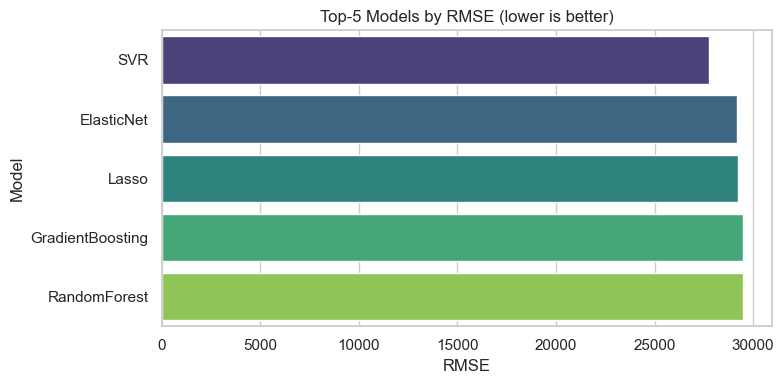

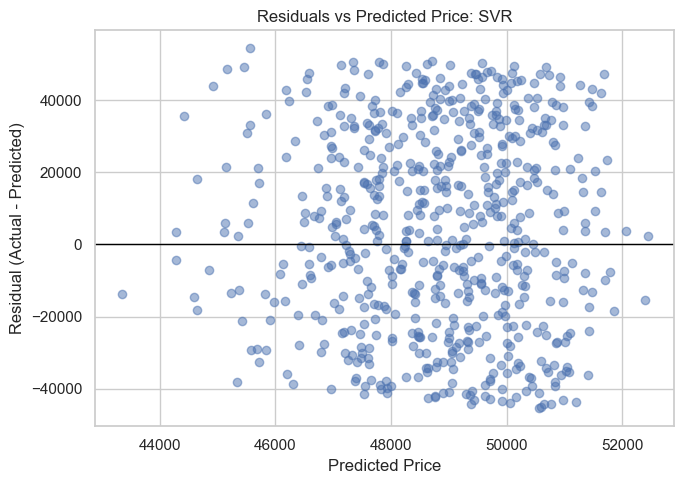

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

top5 = scorecard.head(5).sort_values("rmse", ascending=True)
plt.figure(figsize=(8, 4))
sns.barplot(data=top5, x="rmse", y="model", palette="viridis")
plt.title("Top-5 Models by RMSE (lower is better)")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

best_pred_log = best_model.predict(X_test)
best_pred_price = np.maximum(0, np.expm1(best_pred_log))
residuals = y_test_price - best_pred_price

plt.figure(figsize=(7, 5))
plt.scatter(best_pred_price, residuals, alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Residuals vs Predicted Price: {best_model_name}")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()